# Low-frequency noise analysis

Simple Speckit ASD workflow for rp_ads1278 CSV logs. Change `MEASUREMENT_PATH` and `CHANNEL` for other recordings.

In [22]:
from pathlib import Path

MEASUREMENT_PATH = Path("../logged_files/Better-wiring/ch1-WB-Gain4.csv")
CHANNEL = "ch1"
REFERENCE_VOLTS = 2.5

In [23]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "reference" / "speckit-1.0.2"))

from speckit import compute_single_bin, compute_spectrum

RP_ADC_CLOCK_HZ = 125_000_000.0
ADS1278_CLOCKS_PER_SAMPLE = 512.0
CODE_SCALE = 1 << 23

In [24]:
df = pd.read_csv(MEASUREMENT_PATH)

extclk_div = int(df["extclk_div"].iloc[0])
fs = RP_ADC_CLOCK_HZ / (2.0 * extclk_div) / ADS1278_CLOCKS_PER_SAMPLE

codes = df[CHANNEL].to_numpy(dtype=float)
volts = codes * (REFERENCE_VOLTS / CODE_SCALE)
volts = volts - volts.mean()

duration_s = len(volts) / fs
print(f"Loaded {len(volts):,} samples, fs = {fs:.4f} Hz, duration = {duration_s:.1f} s")

Loaded 6,279,644 samples, fs = 4882.8125 Hz, duration = 1286.1 s


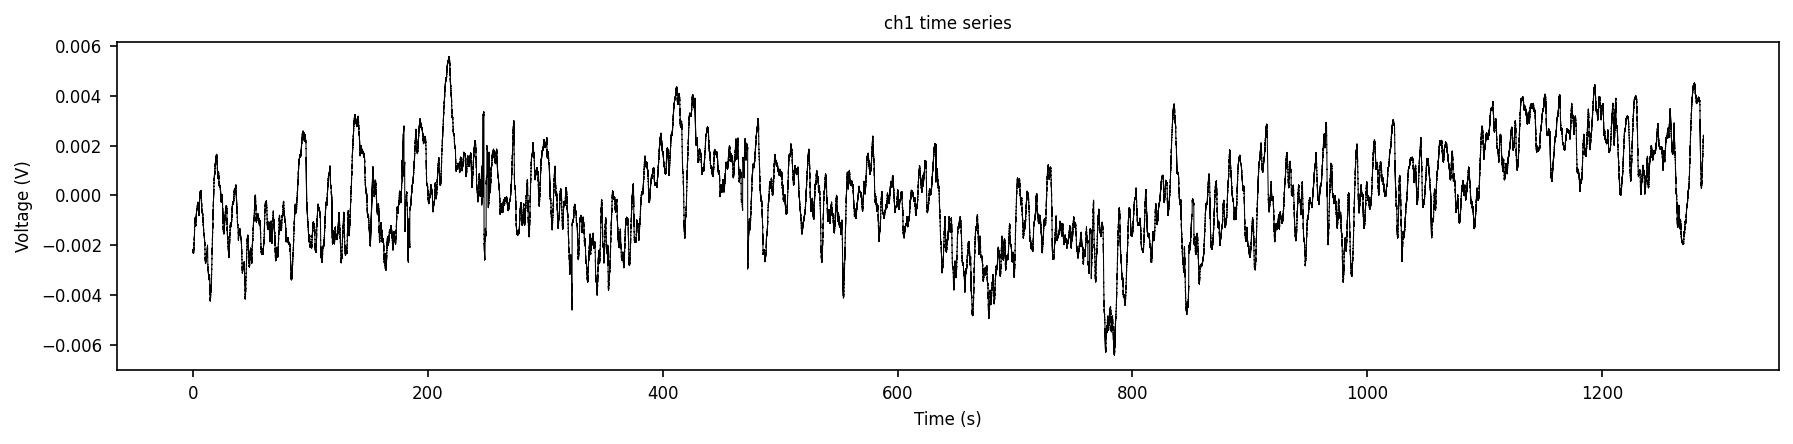

In [25]:
t = np.arange(len(volts)) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, volts, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"{CHANNEL} time series")
plt.tight_layout()
plt.show()

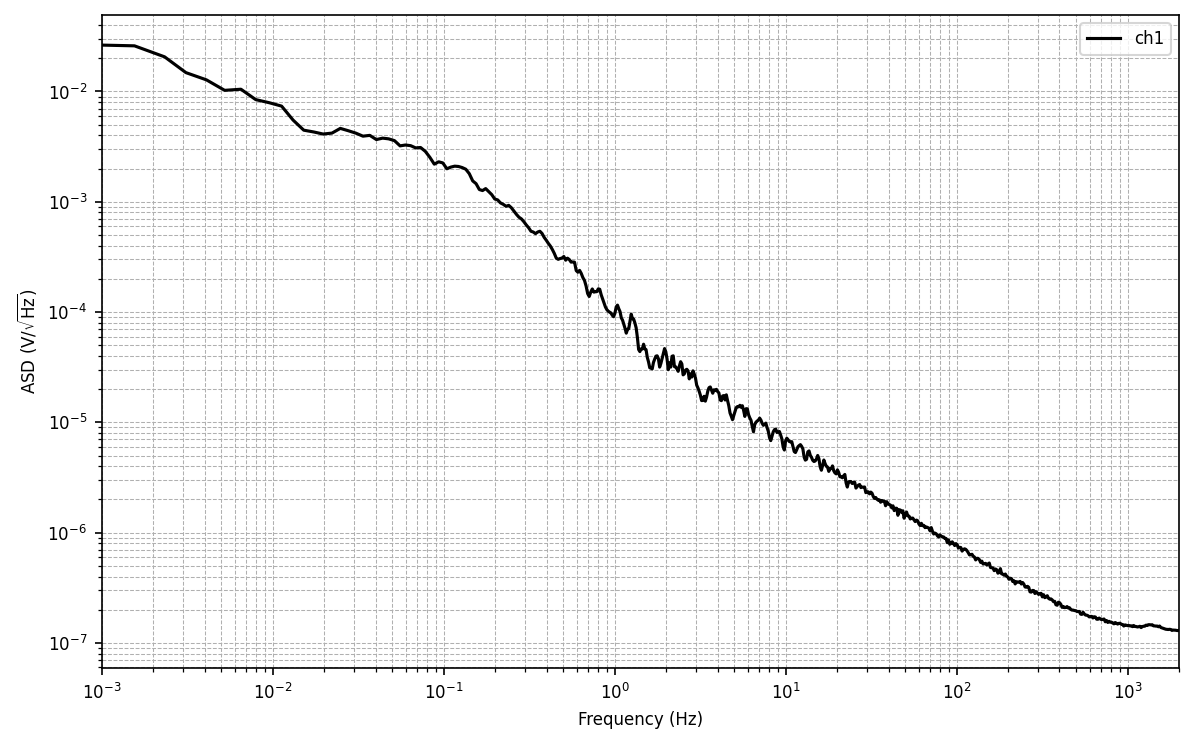

In [29]:
result = compute_spectrum(
    volts,
    fs=fs,
    Jdes=900,
    Kdes=100,
    order=0,
    win="Kaiser",
    psll=200,
    verbose=False,
)

fig, ax = plt.subplots(figsize=(8, 5))
result.plot(which="asd", ax=ax, label=CHANNEL)
ax.set_xlim(0.001, 2000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"ASD (V/$\sqrt{\rm Hz}$)")
ax.legend()
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [9]:
bin_result = compute_single_bin(
    volts,
    fs,
    freq=10.0,
    fres=0.01,
    win="Kaiser",
    psll=200,
)

asd_10hz = float(bin_result.asd[0])
print(f"Noise at 10 Hz: {asd_10hz:.6e} V/sqrt(Hz)")

Noise at 10 Hz: 5.922659e-06 V/sqrt(Hz)
